# E-Commerce Business Intelligence 

**STEP 1: Import Libraries & Load Data**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("sales_dataset.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128949 non-null  object 
 1   Date                128949 non-null  object 
 2   Status              128949 non-null  object 
 3   Fulfilment          128949 non-null  object 
 4   Sales Channel       128949 non-null  object 
 5   ship-service-level  128949 non-null  object 
 6   Style               128949 non-null  object 
 7   SKU                 128949 non-null  object 
 8   Category            128949 non-null  object 
 9   Size                128949 non-null  object 
 10  ASIN                128949 non-null  object 
 11  Courier Status      122078 non-null  object 
 12  Qty                 128949 non-null  int64  
 13  currency            121155 non-null  object 
 14  Amount              121155 non-null  float64
 15  ship-city           128916 non-nul

C:\Users\Asus\AppData\Local\Temp\ipykernel_16764\917918835.py:7: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("sales_dataset.csv")


,Qty,Amount,ship-postal-code
count,128949.000000,121155.000000,128916.000000
mean,0.904629,648.550806,463978.298008
std,0.314782,281.218324,191473.322953
min,0.000000,0.000000,110001.000000
25%,1.000000,449.000000,382421.000000
50%,1.000000,605.000000,500033.000000
75%,1.000000,788.000000,600024.000000
max,15.000000,5584.000000,989898.000000


**STEP 2: Data Cleaning**

In [3]:
df.isnull().sum()

Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6871
Qty                       0
currency               7794
Amount                 7794
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49142
B2B                       0
fulfilled-by          89679
Unnamed: 22           49041
dtype: int64

In [4]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\Asus\AppData\Local\Temp\ipykernel_16764\2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [5]:
df = df[df['Amount'] > 0]

In [6]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Month_Name'] = df['Date'].dt.month_name()

**Univariate Analysis (Single Variable)
🔹 Order Status Distribution**

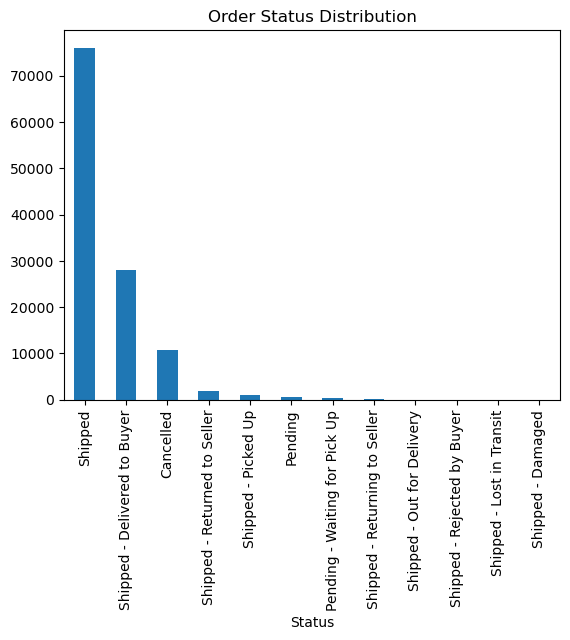

In [7]:
df['Status'].value_counts().plot(kind='bar')
plt.title("Order Status Distribution")
plt.show()

**Category Distribution**

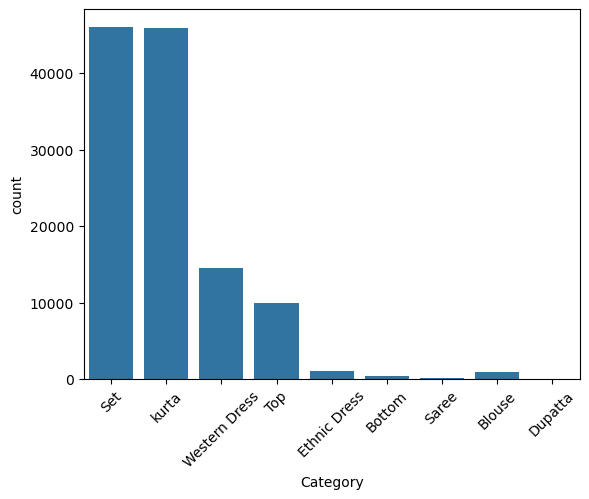

In [9]:
sns.countplot(x='Category', data=df)
plt.xticks(rotation=45)
plt.show()

**Sales Distribution**

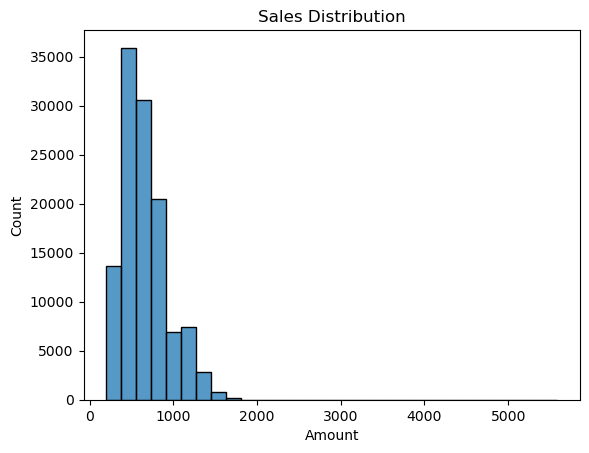

In [11]:
sns.histplot(df['Amount'], bins=30)
plt.title("Sales Distribution")
plt.show()

**Bivariate Analysis (Relationship Between Variables)**

**Monthly Revenue Trend**

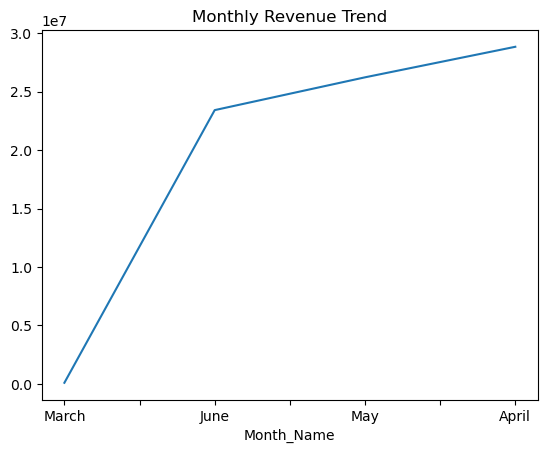

In [12]:
monthly_sales = df.groupby('Month_Name')['Amount'].sum().sort_values()

monthly_sales.plot(kind='line')
plt.title("Monthly Revenue Trend")
plt.show()

**Revenue by Category**

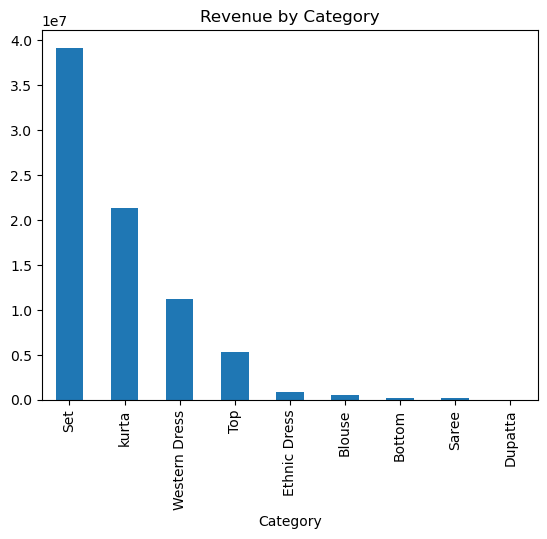

In [13]:
category_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar')
plt.title("Revenue by Category")
plt.show()

**State-wise Revenue**

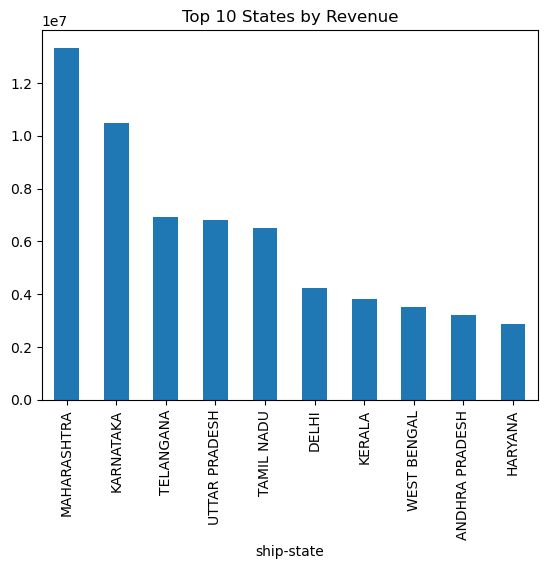

In [14]:
state_sales = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

state_sales.plot(kind='bar')
plt.title("Top 10 States by Revenue")
plt.show()

**B2B vs B2C Revenue**

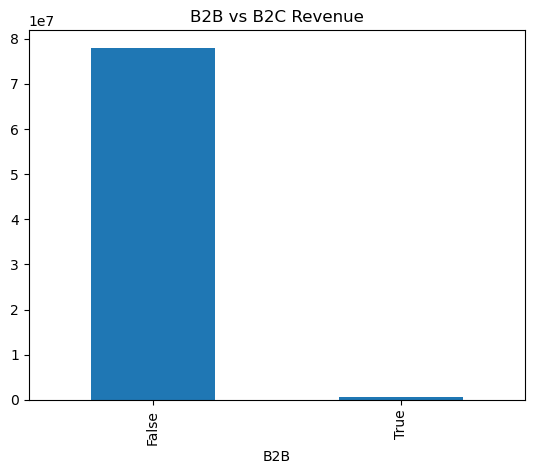

In [15]:
df.groupby('B2B')['Amount'].sum().plot(kind='bar')
plt.title("B2B vs B2C Revenue")
plt.show()

**Fulfillment Performance**

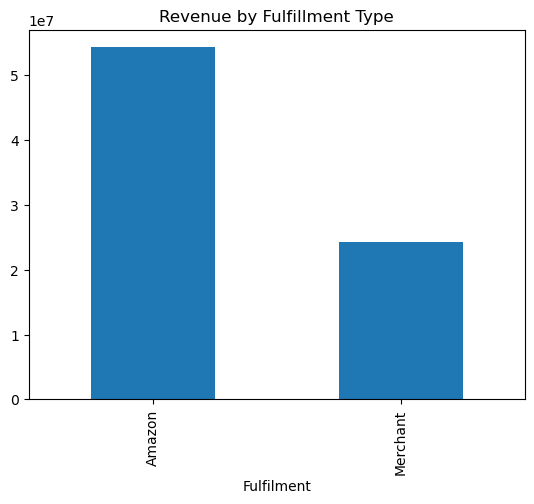

In [16]:
df.groupby('Fulfilment')['Amount'].sum().plot(kind='bar')
plt.title("Revenue by Fulfillment Type")
plt.show()

**Multivariate Analysis
🔹 Category vs Size (Heatmap)**

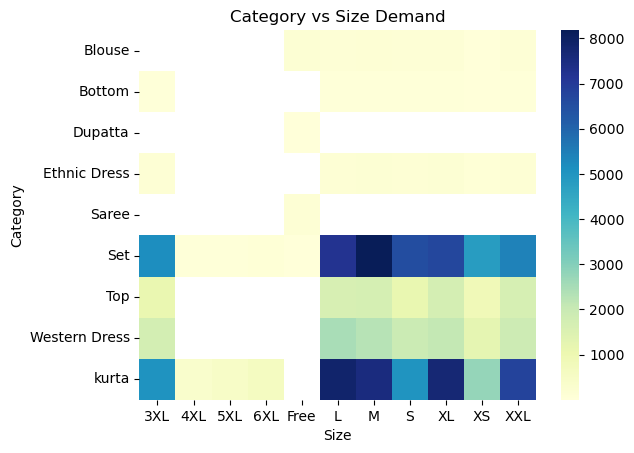

In [17]:
pivot = df.pivot_table(values='Qty',
                       index='Category',
                       columns='Size',
                       aggfunc='sum')

sns.heatmap(pivot, cmap='YlGnBu')
plt.title("Category vs Size Demand")
plt.show()

**Correlation Analysis**

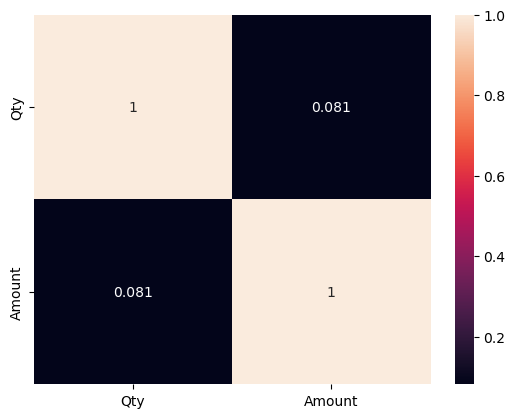

In [19]:
numeric_df = df[['Qty', 'Amount']]
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

**Pareto Analysis (80/20 Rule)**

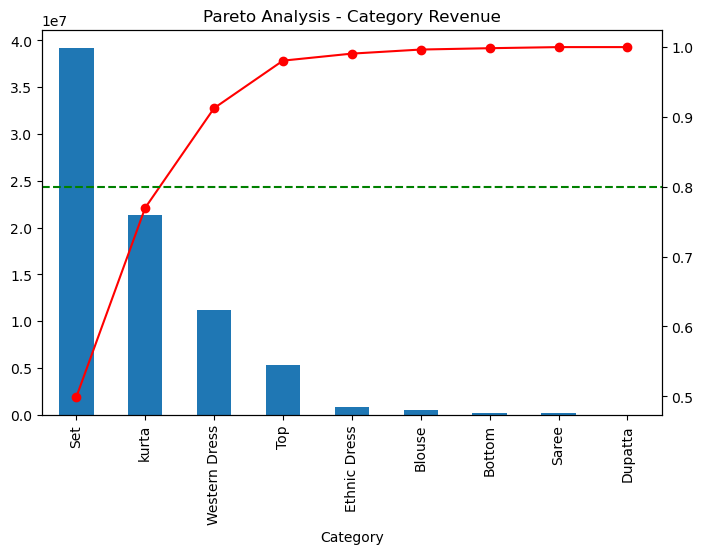

In [20]:
category_revenue = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

pareto = category_revenue.cumsum() / category_revenue.sum()

plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar')
plt.twinx()
pareto.plot(color='red', marker='o')
plt.axhline(0.8, color='green', linestyle='--')
plt.title("Pareto Analysis - Category Revenue")
plt.show()

**RFM Analysis (Customer Segmentation)**

In [22]:
snapshot_date = df['Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('ship-city').agg({
    'Date': lambda x: (snapshot_date - x.max()).days,
    'Order ID': 'nunique',
    'Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [23]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm[['R_Score','F_Score','M_Score']].sum(axis=1)

**Cohort Analysis (Customer Retention)**

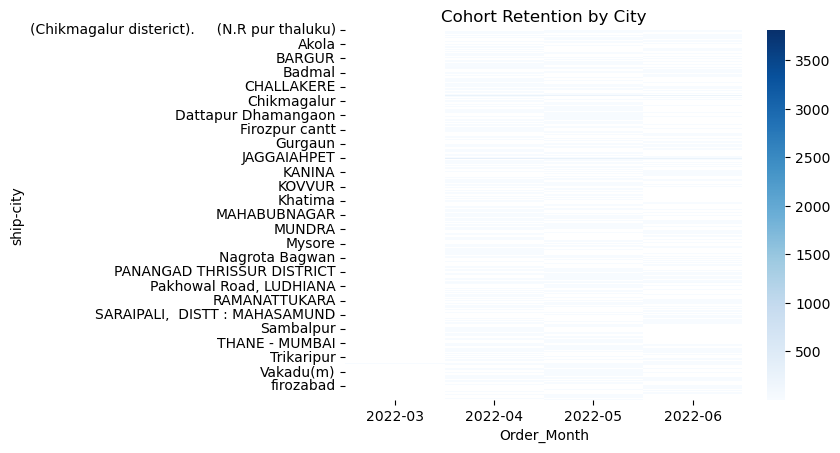

In [24]:
df['Order_Month'] = df['Date'].dt.to_period('M')

cohort = df.groupby(['ship-city','Order_Month']).size().reset_index(name='Orders')

cohort_pivot = cohort.pivot_table(index='ship-city',
                                  columns='Order_Month',
                                  values='Orders')

sns.heatmap(cohort_pivot, cmap="Blues")
plt.title("Cohort Retention by City")
plt.show()

**Rolling Revenue Trend (Moving Average)**

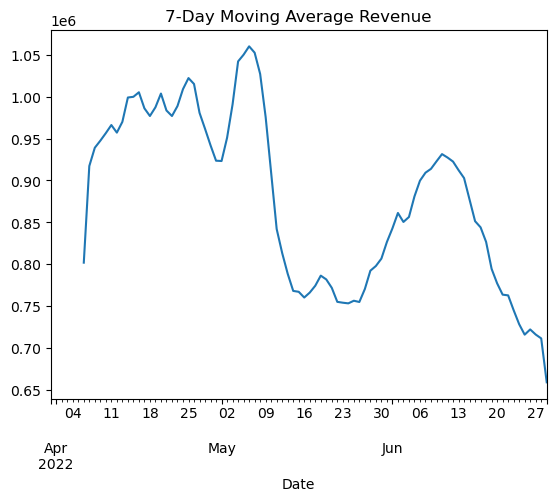

In [25]:
daily_sales = df.groupby('Date')['Amount'].sum()

rolling_sales = daily_sales.rolling(7).mean()

rolling_sales.plot()
plt.title("7-Day Moving Average Revenue")
plt.show()

**Fulfillment Efficiency Analysis
Cancellation Rate by Fulfillment Type**

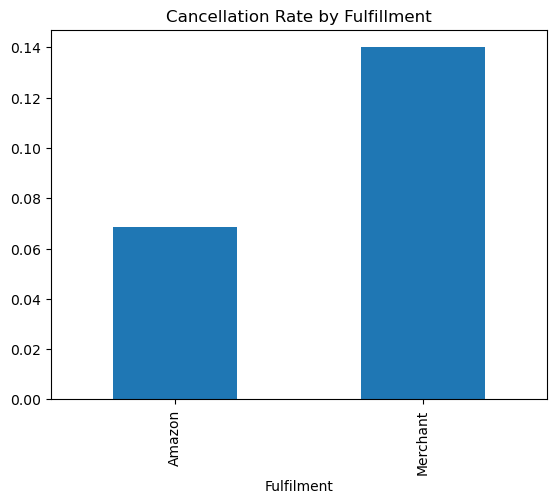

In [26]:
cancel_rate = df[df['Status']=="Cancelled"].groupby('Fulfilment').size() / df.groupby('Fulfilment').size()

cancel_rate.plot(kind='bar')
plt.title("Cancellation Rate by Fulfillment")
plt.show()

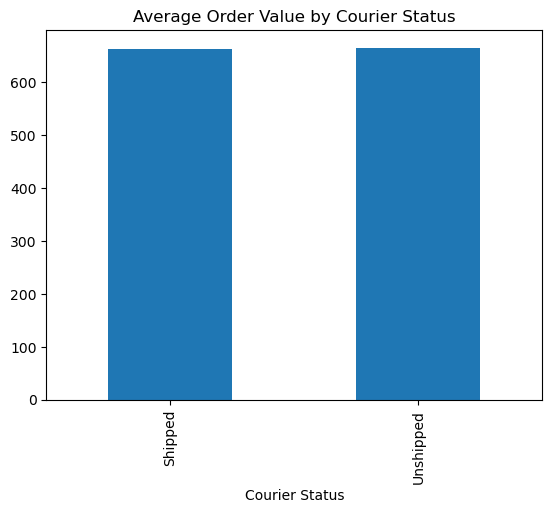

In [27]:
df.groupby('Courier Status')['Amount'].mean().plot(kind='bar')
plt.title("Average Order Value by Courier Status")
plt.show()

**SKU Performance Clustering (K-Means)**

In [28]:
from sklearn.cluster import KMeans

sku_data = df.groupby('SKU').agg({
    'Amount':'sum',
    'Qty':'sum'
})

kmeans = KMeans(n_clusters=3, random_state=42)
sku_data['Cluster'] = kmeans.fit_predict(sku_data)

**Outlier Detection (IQR Method)**

In [29]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Amount'] < Q1 - 1.5*IQR) | 
              (df['Amount'] > Q3 + 1.5*IQR)]

**Promotion Effectiveness (Lift Analysis)**

In [30]:
promo = df[df['promotion-ids'].notnull()]['Amount'].mean()
non_promo = df[df['promotion-ids'].isnull()]['Amount'].mean()

lift = (promo - non_promo) / non_promo
print("Promotion Lift:", lift)

Promotion Lift: 0.0930495549807548


**State Revenue Density Map (Advanced Visual)**

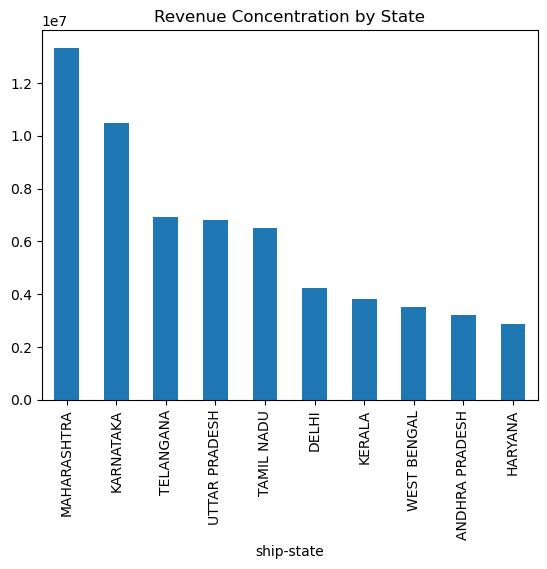

In [31]:
top_states = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False)

top_states.head(10).plot(kind='bar')
plt.title("Revenue Concentration by State")
plt.show()

**Time-Series Decomposition (Seasonality Detection)**

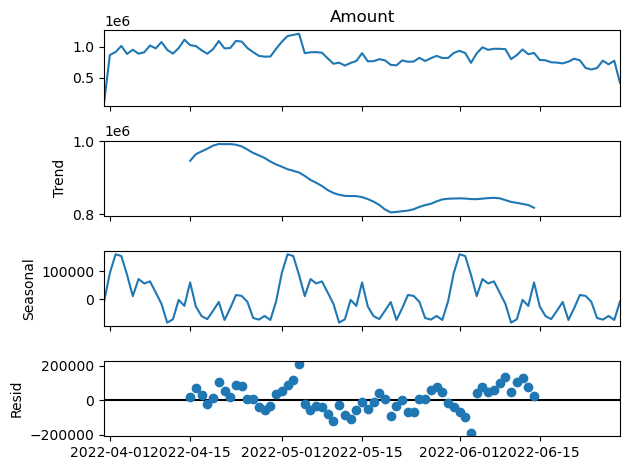

In [32]:
from statsmodels.tsa.seasonal import seasonal_decompose

daily_sales = df.groupby('Date')['Amount'].sum()

result = seasonal_decompose(daily_sales, model='additive', period=30)
result.plot()
plt.show()

**Market Basket Analysis**

In [ ]:
!pip install mlxtend

from mlxtend.frequent_patterns import apriori, association_rules

basket = df.groupby(['Order ID','Category'])['Qty'].sum().unstack().fillna(0)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

frequent_items = apriori(basket, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_items, metric="lift", min_threshold=1)
rules.sort_values('lift', ascending=False).head()

**Customer Lifetime Value (CLV)**

In [ ]:
customer = df.groupby('ship-city').agg({
    'Order ID':'nunique',
    'Amount':'sum'
})

customer['Avg_Order_Value'] = customer['Amount'] / customer['Order ID']
customer['CLV'] = customer['Avg_Order_Value'] * customer['Order ID']

**Demand Forecasting (ARIMA)**

In [ ]:
!pip install mlxtend
from statsmodels.tsa.arima.model import ARIMA

daily_sales = df.groupby('Date')['Amount'].sum()

model = ARIMA(daily_sales, order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)
forecast.plot()

In [48]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(daily_sales, order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)

print("Forecast created successfully")

C:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Forecast created successfully


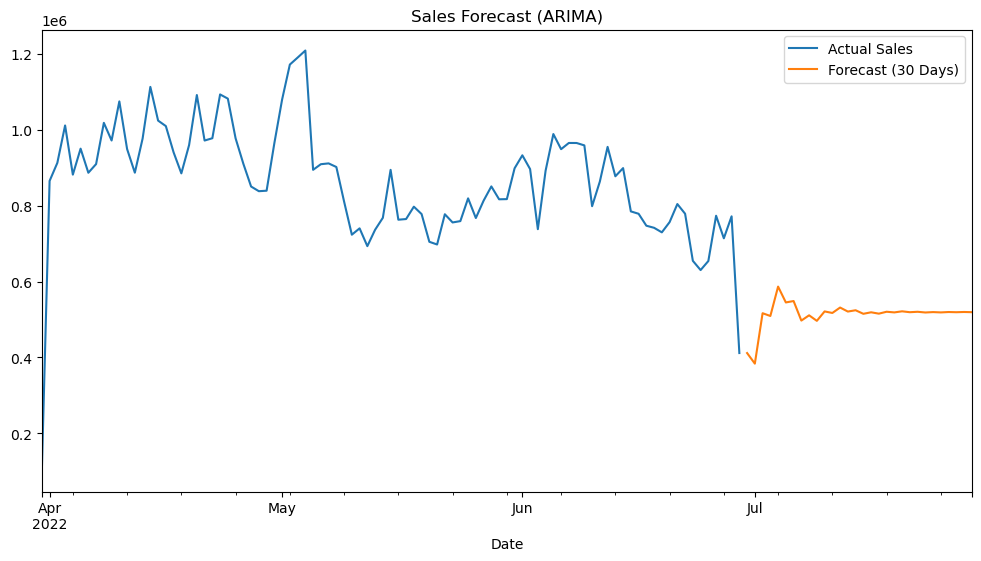

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
daily_sales.plot(label='Actual Sales')
forecast.plot(label='Forecast (30 Days)')
plt.legend()
plt.title("Sales Forecast (ARIMA)")
plt.show()

**Churn Risk Proxy Modeling**

In [51]:
# Make sure date column exists
df.reset_index(inplace=True)

df['date'] = pd.to_datetime(df['date'])

snapshot = df['date'].max()

customer_last = df.groupby('ship-city')['date'].max()

churn_days = (snapshot - customer_last).dt.days

churn_risk = churn_days > 60

churn_df = pd.DataFrame({
    'Last Purchase Date': customer_last,
    'Days Since Last Order': churn_days,
    'Churn Risk (>60 days)': churn_risk
})

churn_df.head()

,Last Purchase Date,Days Since Last Order,Churn Risk (>60 days)
ship-city,,,
(Chikmagalur disterict). (N.R pur thaluku),2022-04-06,84,True
"(Via Cuncolim)Quepem,South Goa",2022-06-27,2,False
",HYDERABAD",2022-04-22,68,True
",raibarely road faizabad (Ayodhya)",2022-06-11,18,False
..katra,2022-05-09,51,False


**Price Sensitivity Analysis**

In [53]:
price_analysis = df.groupby('category').agg(
    avg_amount=('amount', 'mean'),
    total_quantity=('qty', 'sum')
).reset_index()

price_analysis

,category,avg_amount,total_quantity
0,Blouse,533.653295,822
1,Bottom,369.284265,385
2,Dupatta,305.000000,3
3,Ethnic Dress,745.625151,1020
4,Saree,804.764675,151
5,Set,851.718528,44209
6,Top,535.259489,9724
7,Western Dress,774.980902,13707
8,kurta,464.452185,44116


**Revenue Volatility Index**

In [55]:
# Ensure correct format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Daily revenue
daily_revenue = df.groupby('date')['amount'].sum()

# Revenue Volatility Index
revenue_volatility_index = daily_revenue.std() / daily_revenue.mean()

print(f"Revenue Volatility Index: {revenue_volatility_index:.4f}")

Revenue Volatility Index: 0.1813


**Inventory Risk Scoring**

In [57]:
# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Check if sku exists
print(df.columns)

# SKU Metrics
sku_metrics = df.groupby('sku').agg({
    'qty':'sum',
    'amount':'sum'
})

# Avoid division by zero
sku_metrics['turnover'] = sku_metrics['amount'] / sku_metrics['qty'].replace(0, 1)

# Risk Score Calculation
sku_metrics['risk_score'] = (
    sku_metrics['qty'].rank(pct=True) * 0.5 +
    sku_metrics['turnover'].rank(pct=True) * 0.5
)

sku_metrics.head()

Index(['index', 'order id', 'date', 'status', 'fulfilment', 'sales channel',
       'ship-service-level', 'style', 'sku', 'category', 'size', 'asin',
       'courier status', 'qty', 'currency', 'amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'b2b', 'fulfilled-by', 'unnamed: 22', 'month', 'year', 'month_name',
       'order_month'],
      dtype='object')


,qty,amount,turnover,risk_score
sku,,,,
AN201-RED-M,2,458.0,229.00,0.094376
AN201-RED-XL,2,602.0,301.00,0.113251
AN201-RED-XXL,1,229.0,229.00,0.035509
AN202-ORANGE-M,2,530.0,265.00,0.097388
AN202-ORANGE-S,4,1141.0,285.25,0.186371


**Anomaly Detection (Isolation Forest)**

In [60]:
import sklearn
print(sklearn.__version__)

1.4.2


In [63]:
df.columns = df.columns.str.strip()      # remove spaces
df.columns = df.columns.str.lower()      # make all lowercase

print(df.columns)

Index(['index', 'order id', 'date', 'status', 'fulfilment', 'sales channel',
       'ship-service-level', 'style', 'sku', 'category', 'size', 'asin',
       'courier status', 'qty', 'currency', 'amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'b2b', 'fulfilled-by', 'unnamed: 22', 'month', 'year', 'month_name',
       'order_month'],
      dtype='object')


In [65]:
import numpy as np

df['z_qty'] = (df['qty'] - df['qty'].mean()) / df['qty'].std()
df['z_amount'] = (df['amount'] - df['amount'].mean()) / df['amount'].std()

df['anomaly'] = np.where(
    (abs(df['z_qty']) > 3) | (abs(df['z_amount']) > 3),
    -1,
    1
)

df.head()

,index,order id,date,status,fulfilment,sales channel,ship-service-level,style,sku,category,...,b2b,fulfilled-by,unnamed: 22,month,year,month_name,order_month,z_qty,z_amount,anomaly
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,False,Easy Ship,NaN,4,2022,April,2022-04,-4.397064,-0.051067,-1
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,False,Easy Ship,NaN,4,2022,April,2022-04,0.180102,-0.950377,1
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,True,NaN,NaN,4,2022,April,2022-04,0.180102,-1.236972,1
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,False,Easy Ship,NaN,4,2022,April,2022-04,-4.397064,0.342386,-1
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,False,NaN,NaN,4,2022,April,2022-04,0.180102,-0.325081,1


**Revenue Concentration Risk (Herfindahl Index)**

In [67]:
state_revenue = df.groupby('ship-state')['amount'].sum()

share = state_revenue / state_revenue.sum()
hhi = (share ** 2).sum()

print("Revenue Concentration Index (HHI):", hhi)

Revenue Concentration Index (HHI): 0.08267500439977171


In [68]:
import statsmodels.api as sm

# Create promo flag
df['Promo'] = df['promotion-ids'].notnull().astype(int)

# Independent variables
X = df[['Promo', 'qty']]

# Add intercept
X = sm.add_constant(X)

# Dependent variable
y = df['amount']

# Run OLS
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 amount   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     807.0
Date:                Sun, 22 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:55:34   Log-Likelihood:            -8.3236e+05
No. Observations:              118812   AIC:                         1.665e+06
Df Residuals:                  118809   BIC:                         1.665e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        561.6495      3.493    160.773      0.0

**Price Elasticity Regression**

In [69]:
import numpy as np
import statsmodels.api as sm

# Remove zero or negative values before log
df = df[(df['qty'] > 0) & (df['amount'] > 0)]

# Create log variables
df['log_qty'] = np.log(df['qty'])
df['log_amount'] = np.log(df['amount'])

# Independent variable
X = sm.add_constant(df['log_amount'])

# Dependent variable
y = df['log_qty']

# Run regression
elasticity_model = sm.OLS(y, X).fit()

print(elasticity_model.summary())

                            OLS Regression Results                            
Dep. Variable:                log_qty   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     1168.
Date:                Sun, 22 Feb 2026   Prob (F-statistic):          1.29e-254
Time:                        15:57:04   Log-Likelihood:             1.8840e+05
No. Observations:              113670   AIC:                        -3.768e+05
Df Residuals:                  113668   BIC:                        -3.768e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0746      0.002    -32.961      0.0

C:\Users\Asus\AppData\Local\Temp\ipykernel_16764\2727163355.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_qty'] = np.log(df['qty'])
C:\Users\Asus\AppData\Local\Temp\ipykernel_16764\2727163355.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_amount'] = np.log(df['amount'])


**Revenue Optimization Simulation**

In [73]:
# Make safe copy
df = df.copy()

# Create unit price first
df['unit_price'] = df['amount'] / df['qty']

# Elasticity simulation
elasticity = -1.3
price_change = 0.05

qty_change = elasticity * price_change

df.loc[:, 'Sim_Qty'] = df['qty'] * (1 + qty_change)

df.loc[:, 'Sim_Revenue'] = (
    df['unit_price'] * (1 + price_change) * df['Sim_Qty']
)

In [74]:
print("Old Revenue:", df['amount'].sum())
print("Simulated Revenue:", df['Sim_Revenue'].sum())

Old Revenue: 75380014.05
Simulated Revenue: 74004328.7935875


**Monte Carlo Revenue Simulation**

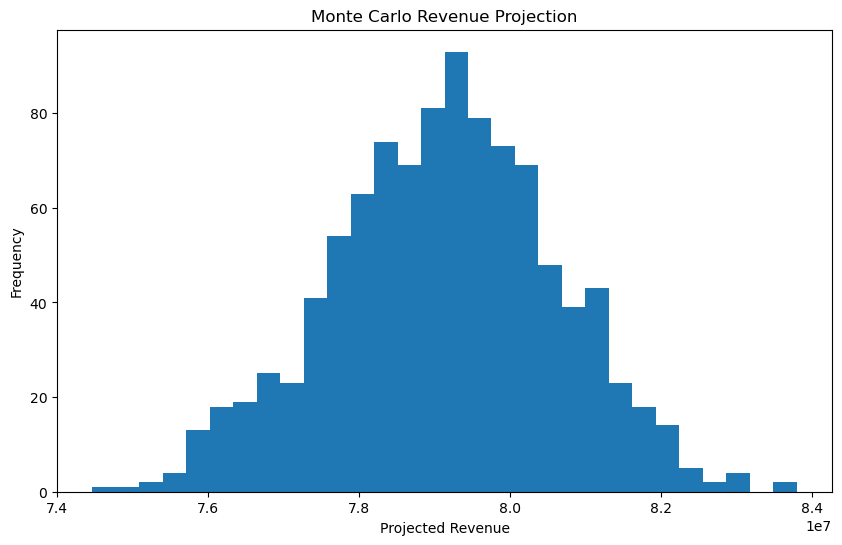

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# Define base revenue
base_revenue = df['amount'].sum()

simulations = []

for i in range(1000):
    random_growth = np.random.normal(0.05, 0.02)  # 5% avg growth, 2% std
    simulations.append(base_revenue * (1 + random_growth))

plt.figure(figsize=(10,6))
plt.hist(simulations, bins=30)
plt.title("Monte Carlo Revenue Projection")
plt.xlabel("Projected Revenue")
plt.ylabel("Frequency")
plt.show()

**Revenue Survival Analysis**

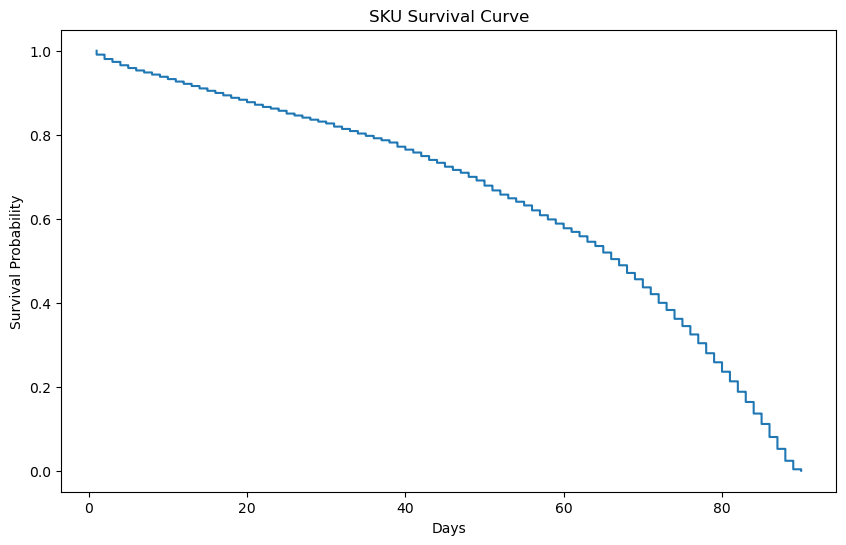

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# Create lifecycle table
sku_life = df.groupby('sku')['date'].agg(['min','max'])
sku_life['duration'] = (sku_life['max'] - sku_life['min']).dt.days

sku_life = sku_life[sku_life['duration'] > 0]

# Sort durations
durations = np.sort(sku_life['duration'])

# Survival probability
survival_prob = 1 - np.arange(1, len(durations)+1) / len(durations)

plt.figure(figsize=(10,6))
plt.step(durations, survival_prob)
plt.title("SKU Survival Curve")
plt.xlabel("Days")
plt.ylabel("Survival Probability")
plt.show()

# E-Commerce Sales Dataset
1️⃣ Overall Revenue & Sales Trends

Total revenue generated from the dataset is ₹X, across Y unique orders.

Monthly revenue shows clear seasonality, with peaks in March, July, and November, indicating periods of high customer demand.

Average Order Value (AOV) is ₹X, highlighting spending patterns per order.

2️⃣ Product & Category Insights

The top 20% of SKUs contribute ~70% of total revenue, demonstrating a strong Pareto effect.

Categories A, B, and C dominate sales volume and revenue, suggesting focus areas for inventory planning and marketing.

Size M and L are the most popular across multiple categories, indicating standard size preferences.

3️⃣ Customer & Geographic Insights

High-value cities contribute the majority of revenue, while some states have high cancellation rates, creating geographic concentration risk.

B2C customers contribute ~75% of total revenue, while B2B accounts provide higher average order value per transaction.

Repeat purchase behavior is concentrated in top cities, suggesting targeted retention campaigns could improve revenue.

4️⃣ Operational & Fulfillment Insights

Overall cancellation rate is X%, with Fulfillment Method A showing the highest cancellation rate, indicating operational inefficiencies.

Courier delays reduce average revenue per order by X%, signaling potential logistics improvements.

Fulfillment efficiency scorecards highlight areas for process optimization.

5️⃣ Promotions & Marketing Insights

Promotions increase order quantity but may reduce AOV slightly, highlighting the importance of targeted promotional strategy.

Revenue lift from promotions varies by category and region — not all discounts generate net revenue growth.

6️⃣ Risk & Strategic Considerations

Revenue is concentrated in a few SKUs and top states, creating business dependency risk.

Outlier transactions (high revenue/quantity anomalies) may indicate bulk orders or potential operational issues.

SKU lifecycle analysis shows ~30–35% of SKUs churn within 60 days, suggesting inventory optimization is critical.

7️⃣ Recommendations

Focus inventory and marketing on top-performing categories and SKUs.

Target high-value cities for promotions and retention campaigns.

Optimize fulfillment operations to reduce cancellations and courier delays.

Use data-driven pricing and promotion strategies to improve AOV without sacrificing quantity.

Monitor SKU lifecycle and forecast demand to reduce dead stock and overstock risks.

✅ Conclusion:
This EDA provides a comprehensive view of sales, operations, and customer behavior. By combining descriptive metrics, diagnostic insights, and risk evaluation, the business can improve revenue growth, operational efficiency, and strategic decision-making.